In [4]:
context_size = 10
batch_size = 128
import re

def clean_text(text, pattern = r'[^a-zA-Z0-9 \.\n]'):
  text = text.lower()
  text = text.replace("<bos>", "BOSTOKEN")
  text = re.sub(pattern, '', text)
  text = text.replace("BOSTOKEN", "<bos>")
  return text

pattern = r"""
    <bos>|<eos>|<unk>|         
    //.*|                      
    /\*[\s\S]*?\*/|           
    \#.*|         
    "(?:\\.|[^"\\])*"|         
    '(?:\\.|[^'\\])*'|
    \$\{?[A-Za-z_][A-Za-z0-9_]*\}?|  
    [A-Za-z_][A-Za-z0-9_]*|
    [0-9]+(?:\.[0-9]+)?|       
    [|&;><!~^%*/=+\-]=?|      
    [(){}\[\],.]|             
    [A-Za-z0-9_\-./]+|         
    \n                        
"""

class Tokenizer:

  def __init__(self, vocab_size = 2 ** 16) -> None:
    self.vocab_size = vocab_size
    self.word_to_idx = {}
    self.idx_to_word = {}
    self.word_freq = {}

  def build_vocab(self, text):
    # text = clean_text(text, self.pattern)
    text = text.lower()

    words = re.findall(pattern, text, flags=re.VERBOSE)
    unique_words = list(set(words))
    # print(pattern)
    print(len(text))
    print(len(words))
    for idx, word in enumerate(unique_words):
      self.word_freq[word] = words.count(word)

    sorted_words = sorted(self.word_freq.items(), key=lambda x: x[1], reverse=True)
    top_words = sorted_words[:int(self.vocab_size)]

    for idx, (word, _) in enumerate(top_words):

      self.word_to_idx[word] = idx
      self.idx_to_word[idx] = word

    self.word_to_idx['<UNK>'] = len(self.word_to_idx)
    self.idx_to_word[len(self.idx_to_word)] = '<UNK>'

  def encode(self, text):
    # text = clean_text(text, self.pattern)
    words = re.findall(pattern, text, flags=re.VERBOSE)
    encoded_text = []
    for word in words:
      if word in self.word_to_idx:
        encoded_text.append(self.word_to_idx[word])
      else:
        encoded_text.append(self.word_to_idx['<UNK>'])
    return encoded_text

  def decode(self, idxs):
    words = []
    for idx in idxs:
      if idx in self.idx_to_word:
        words.append(self.idx_to_word[idx])
      else:
        words.append('<UNK>')

    return ' '.join(words)

In [8]:
with open("linux_input.txt", "r", encoding = "iso-8859-1") as f:
    corpus = f.read()

corpus = corpus.replace("\n\n", "\n\n" + "<bos>" * context_size)


In [5]:
import pickle
# tokenizer = Tokenizer()
# tokenizer.build_vocab(corpus)

# tokenizer.word_to_idx["<bos>"] = len(tokenizer.word_to_idx)
# tokenizer.idx_to_word[len(tokenizer.idx_to_word)] = "<bos>"


# with open("outputs_2/tokenizer_2.pkl", "wb") as f:
#     pickle.dump(tokenizer, f)

tokenizer = pickle.load(open("outputs_2/tokenizer_2.pkl", "rb"))

vocab_size = len(tokenizer.word_to_idx)
print(vocab_size)

44360


In [6]:
def make_X_y_pairs(corpus, bos_token = "<bos>", context_size = context_size):
  ## text is a list of sentences
  X = []
  y = []
  corpus = context_size * bos_token + corpus
  encoded_text = tokenizer.encode(corpus)
  for i in range(context_size, len(encoded_text)):
    context = encoded_text[i-context_size:i]
    target = encoded_text[i]
    if([target] == tokenizer.encode("<bos>") or [target] == tokenizer.encode('<UNK>')):
        continue
    X.append(context)
    y.append(target)
  return X, y

In [9]:
X, y = make_X_y_pairs(corpus)
for i in range(400,450):
  print(repr(tokenizer.decode(X[i])), "----->",repr(tokenizer.decode([y[i]])))

'\n struct irq_desc * desc ; \n int i ;' -----> '\n'
'struct irq_desc * desc ; \n int i ; \n' -----> '\n'
'<bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos>' -----> 'for_each_irq_desc'
'<bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> for_each_irq_desc' -----> '('
'<bos> <bos> <bos> <bos> <bos> <bos> <bos> <bos> for_each_irq_desc (' -----> 'i'
'<bos> <bos> <bos> <bos> <bos> <bos> <bos> for_each_irq_desc ( i' -----> ','
'<bos> <bos> <bos> <bos> <bos> <bos> for_each_irq_desc ( i ,' -----> 'desc'
'<bos> <bos> <bos> <bos> <bos> for_each_irq_desc ( i , desc' -----> ')'
'<bos> <bos> <bos> <bos> for_each_irq_desc ( i , desc )' -----> '{'
'<bos> <bos> <bos> for_each_irq_desc ( i , desc ) {' -----> '\n'
'<bos> <bos> for_each_irq_desc ( i , desc ) { \n' -----> 'raw_spin_lock_irq'
'<bos> for_each_irq_desc ( i , desc ) { \n raw_spin_lock_irq' -----> '('
'for_each_irq_desc ( i , desc ) { \n raw_spin_lock_irq (' -----> '&'
'( i , desc ) { \n raw_spin_lock_irq ( &' -----> 'desc'
'i , d

In [10]:
import torch
class dataloader():
  def __init__(self, X, y, batch_size = batch_size):
    self.X = X
    self.y = y
    self.batch_size = batch_size
  
  def __len__(self):
    return len(self.X) // batch_size
  
  def __iter__(self):

    for i in range(0, len(self.X), self.batch_size):
      X_batch = self.X[i:i+self.batch_size]
      y_batch = self.y[i:i+self.batch_size]

      yield torch.tensor(X_batch), torch.tensor(y_batch)


train_dataloader = dataloader(X, y)
val_dataloader = dataloader(X[:batch_size*100], y[:batch_size*100], batch_size=batch_size)

In [12]:
import torch.nn as nn
import torch

class Model(nn.Module):

  def __init__(self, vocab_size, embedding_dim = 32, hidden_dim = 1024, context_size = context_size):
    super(Model, self).__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim)
    self.hidden_layer1 = nn.Linear(embedding_dim * context_size, hidden_dim)
    self.relu1 = nn.ReLU()
    self.hidden_layer2 = nn.Linear(hidden_dim, hidden_dim)
    self.relu2 = nn.ReLU()
    self.classifier = nn.Linear(hidden_dim, vocab_size)
    self.dropout1 = nn.Dropout(p=0.3)
    self.dropout2 = nn.Dropout(p=0.3)

  def forward(self, x):
    x = self.embedding(x)
    x = x.view(x.size(0), -1)
    x = self.relu1(self.hidden_layer1(x))
    # x = self.dropout1(x)
    x = self.relu2(self.hidden_layer2(x))
    # x = self.dropout2(x)
    x = self.classifier(x) ## logits

    # x = self.softmax(self.classifier(x))

    return x

model = Model(vocab_size = vocab_size+10)

In [13]:
def generate(model, prompt):

  model.eval()
  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  prompt = tokenizer.encode(prompt)
  prompt = tokenizer.encode("<bos>") * (max(0, context_size-len(prompt))) + prompt
  prompt = torch.tensor(prompt).unsqueeze(0).to(device)
  generated = []
  
  for _ in range(20):
    with torch.no_grad():
      output = model(prompt[:,-context_size:])
      output = torch.argmax(output, dim=1)
      prompt = torch.cat((prompt, output.unsqueeze(0)), dim=1)
      # print(prompt.shape)
      # print(output)
      generated.append(output.item())

  return tokenizer.decode(generated)

In [14]:
def evaluate(model, epoch):
    linux_prompts = [
    "int main(int argc, char *argv[]) {\n    ",
    "for (int i = 0; i < n; i++) {\n        ",
    "if (fork() == 0) {\n        ",
    "while ((read_bytes = read(fd, buffer, sizeof(buffer))) > 0) {\n        ",
    "struct file *filp = filp_open(path, O_RDONLY, 0);\nif (!IS_ERR(filp)) {\n    ",
    "ssize_t bytes = write(fd, data, len);\nif (bytes < 0) {\n    ",
    "pthread_t thread;\npthread_create(&thread, NULL, ",
    "char *line = NULL;\nsize_t len = 0;\nwhile (getline(&line, &len, stdin) != -1) {\n    ",
    "int sock = socket(AF_INET, SOCK_STREAM, 0);\nif (sock < 0) {\n    ",
    "pid_t pid = fork();\nif (pid == 0) {\n    ",
    "FILE *fp = fopen(\"/proc/meminfo\", \"r\");\nif (fp) {\n    ",
    "switch (errno) {\n    case EACCES:\n        ",
    "for (struct list_head *pos = head->next; pos != head; pos = pos->next) {\n    ",
    "module_init(init_module);\nmodule_exit(cleanup_module);\n\nstatic int __init init_module(void) {\n    ",
    "char *args[] = {\"ls\", \"-l\", NULL};\nexecvp(args[0], args);\n",
    "struct sockaddr_in server_addr;\nmemset(&server_addr, 0, sizeof(server_addr));\nserver_addr.sin_family = AF_INET;\nserver_addr.sin_port = htons(8080);\n",
    "int fd = open(\"/dev/null\", O_WRONLY);\nif (fd < 0) {\n    ",
    "signal(SIGINT, handle_signal);\nwhile (1) {\n    ",
    "printf(\"Usage: %s <filename>\\n\", argv[0]);\nreturn ",
    "char buffer[1024];\nmemset(buffer, 0, sizeof(buffer));\n"
  ]

    generated_texts = [f"\n{prompt}: {generate(model, prompt)}\n" for prompt in linux_prompts]
    
    with open("outputs_2/linux-generations2.txt", "a") as file:
        file.write(f"\nGeneration on epoch: {epoch+1}\n")
        file.write(50*"*")
        file.writelines(generated_texts)
        file.write(50*"*")

from tqdm.notebook import tqdm

train_loss_avg = []
val_loss_avg = []

def train(model, train_dataloader, val_dataloader, epochs = 50):

  device = "cuda" if torch.cuda.is_available() else "cpu"
  model.to(device)
  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
  criterion = nn.functional.cross_entropy
  train_losses = []
  val_losses = []

  for epoch in range(epochs):
    model.train()
    # print(f"Epoch {epoch+1}")
    progress = tqdm(train_dataloader, desc=f"Epoch {epoch+1}", dynamic_ncols=True, leave=False)
    running_loss = 0.0
    
    for i, batch in enumerate(progress):
      optimizer.zero_grad()
      X, y = batch
      X = X.to(device)
      y = y.to(device)
      y_pred = model(X)
      loss = criterion(y_pred, y)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()          
      train_losses.append(loss.detach().item())
      progress.set_postfix({'loss': loss.item()})
    
    train_loss_avg.append(running_loss/(len(train_dataloader)))

    running_loss = 0.0
    with torch.no_grad():
      model.eval()
      evaluate(model, epoch)
      for batch in val_dataloader:
        X, y = batch
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = criterion(y_pred, y)
        val_losses.append(loss.detach().item())
      
      val_loss_avg.append(running_loss/len(val_dataloader))

    if epoch % 25 == 0:
      PATH = f"outputs_2/model_epoch{epoch}_2.pth"
      torch.save(model.state_dict(), PATH)
  return train_losses, val_losses


In [15]:
epochs = 26
import numpy as np
train_losses, val_losses = train(model, train_dataloader, train_dataloader, epochs)

train_num_batches = len(train_losses) // epochs
train_loss_per_epoch = [
    np.mean(train_losses[i * train_num_batches : (i + 1) * train_num_batches])
    for i in range((len(train_losses) + train_num_batches - 1) // train_num_batches)
]

val_num_batches = len(val_losses) // epochs

val_loss_per_epoch = [
    np.mean(val_losses[i * val_num_batches : (i + 1) * val_num_batches])
    for i in range((len(val_losses) + val_num_batches - 1) // val_num_batches)
]

Epoch 1:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 5:   0%|          | 0/8755 [00:00<?, ?it/s]

...

Epoch 22:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 23:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 24:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 25:   0%|          | 0/8755 [00:00<?, ?it/s]

Epoch 26:   0%|          | 0/8755 [00:00<?, ?it/s]

In [16]:
np.save('outputs_2/train_loss_0-100.npy', train_loss_per_epoch)
np.save('outputs_2/val_loss_0-100.npy', val_loss_per_epoch)

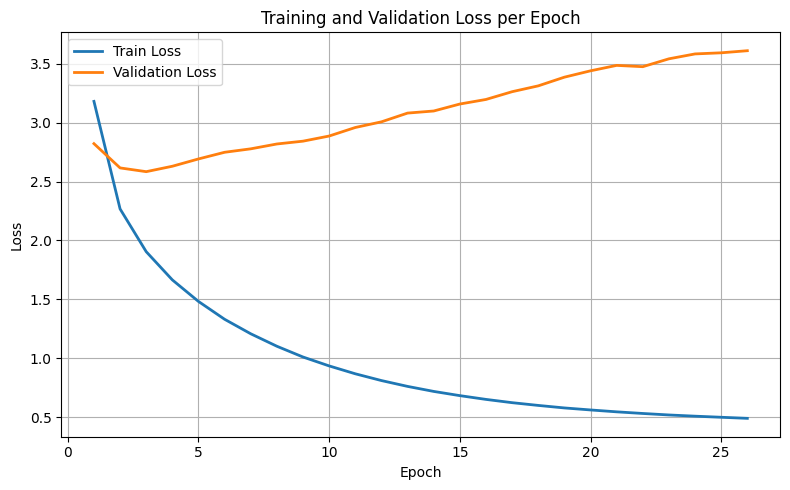

In [17]:
import numpy as np
# train_loss_per_epoch = np.load("outputs/train_loss_0-100.npy")
# val_loss_per_epoch = np.load("outputs/val_loss_0-100.npy")
import matplotlib.pyplot as plt

epochs = range(1, len(train_loss_per_epoch) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss_per_epoch, label='Train Loss', linewidth=2)
plt.plot(epochs, val_loss_per_epoch, label='Validation Loss', linewidth=2)

plt.title("Training and Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
